In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
import numpy as np

# 1. Création du jeu de données
X, y = make_moons(n_samples=1000, noise=0.1, random_state=42)

# Conversion en tenseurs PyTorch
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

# Division entraînement/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Forme X_train: {X_train.shape}, y_train: {y_train.shape}")

Forme X_train: torch.Size([800, 2]), y_train: torch.Size([800])


In [2]:
class MoonModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Linear(in_features=2, out_features=10),
            nn.ReLU(),
            nn.Linear(in_features=10, out_features=10),
            nn.ReLU(),
            nn.Linear(in_features=10, out_features=1)
        )

    def forward(self, x):
        return self.layer_stack(x)

model = MoonModel()
display(model)

MoonModel(
  (layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=10, bias=True)
    (1): ReLU()
    (2): Linear(in_features=10, out_features=10, bias=True)
    (3): ReLU()
    (4): Linear(in_features=10, out_features=1, bias=True)
  )
)

In [3]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

In [4]:
torch.manual_seed(42)
epochs = 1000

for epoch in range(epochs):
    model.train()
    y_logits = model(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))

    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_train, y_pred)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.inference_mode():
        test_logits = model(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))
        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_test, test_pred)

    if epoch % 100 == 0:
        print(f"Époque: {epoch} | Perte: {loss:.5f}, Acc: {acc:.2f}% | Perte test: {test_loss:.5f}, Acc test: {test_acc:.2f}%")

    if test_acc > 96 and epoch > 200:
        print(f"Objectif atteint à l'époque {epoch}!")
        break

Époque: 0 | Perte: 0.70870, Acc: 50.00% | Perte test: 0.70667, Acc test: 50.00%
Époque: 100 | Perte: 0.43972, Acc: 83.00% | Perte test: 0.45165, Acc test: 81.50%
Époque: 200 | Perte: 0.26426, Acc: 88.12% | Perte test: 0.26414, Acc test: 87.00%
Époque: 300 | Perte: 0.24159, Acc: 88.12% | Perte test: 0.23450, Acc test: 89.00%
Époque: 400 | Perte: 0.22420, Acc: 89.50% | Perte test: 0.21482, Acc test: 92.00%
Époque: 500 | Perte: 0.19947, Acc: 91.12% | Perte test: 0.18758, Acc test: 92.50%
Époque: 600 | Perte: 0.16605, Acc: 92.88% | Perte test: 0.15241, Acc test: 93.50%
Objectif atteint à l'époque 691!


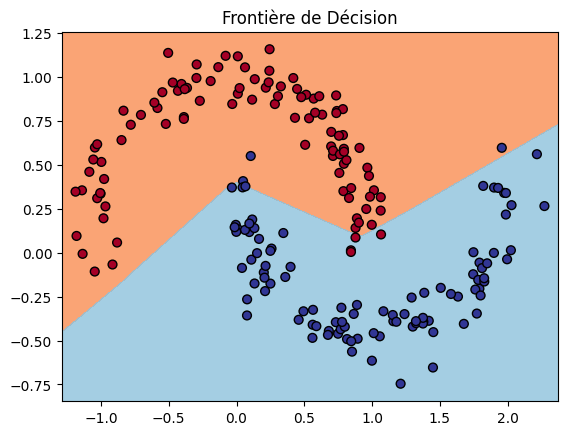

In [5]:
def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

    model.eval()
    with torch.inference_mode():
        grid = torch.from_numpy(np.c_[xx.ravel(), yy.ravel()]).type(torch.float)
        probs = torch.sigmoid(model(grid)).reshape(xx.shape)

    plt.contourf(xx, yy, probs, levels=[0, 0.5, 1], cmap=plt.cm.RdYlBu, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu, edgecolors='k')
    plt.title("Frontière de Décision")
    plt.show()

plot_decision_boundary(model, X_test, y_test)